In [ ]:
在降维可视化过程中，没有先对数据进行归一化（标准化）处理，在后续中需要注意
特征分布还可以考虑使用1-electronic-v2-moreK-sampling-minusY文件中的表达，对角是直方图，其余散点图的形式
Xfig=np.vstack((np.array(X.T),y)).T
#print(Xfig)
plot_feature_relation(Xfig,col=['VMo','VW','VCu','Vpore','Mo-xW-EC','Mo-xW-pore-EC','Cu-pore-EC','Mo-xW-Cu-EC','EC'],y_label='EC',output=True,fname='Feature_corr_dist',plt_prop=True,patt='rainbow')
#plot_feature_relation(X,col=['VMo(%)','VW(%)','VCu(%)','Vpore(%)','Mo-xW-EC','Mo-xW-pore-EC','Cu-pore-EC','Mo-xW-Cu-EC'],output=False,fname='test',plt_prop=True,patt='Set2')

# 在ρ0λ的全部数据模型中 38条数据(去除较大的数值，保留训练用的数据)，全部特征的数据分布--直方图，密度估计图 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from modules import *
import modules


def all_data(File):
    data1=open(File,'r+')
    all=[]
    for i, line in enumerate(data1):
        data=line.split()
        #for j in range(int(len(data))-2):
        #    X += [float(data[j+1])]
        for j in range(int(len(data))):
            all += [float(data[j])]
    m=len(all)
    
    all=np.array(all).reshape(int(627),int(m/627))
   
    return all


File = '../data.4/em-wt-10'
all= all_data(File)
all=all[:38,:]
all=np.delete(all,[7],axis=1)

# 指定列名
column_names = ['weight', 'VEC', 'AR','EN','Ea','1 st','boiling point','ρ0λ']

# 将NumPy数组转换为Pandas DataFrame，并指定列名
df = pd.DataFrame(all, columns=column_names)


In [1]:
"""
直方图
"""
# 设置图形的风格
sns.set(style="whitegrid")
# 绘制特征的直方图
fig, axes = plt.subplots(2, 4, figsize=(25, 15))

# for i, feature in enumerate(df.columns[:-1]):  # 假设最后一列是目标值
#     sns.histplot(df[feature], ax=axes[i//4, i%4], kde=True)
#     axes[i//4, i%4].set_title(f'Distribution of {feature}',fontsize=25)
  
axes = axes.flatten()  # 将二维数组展平为一维
# 绘制每个特征列的分布图
for i, feature in enumerate(df.columns):
    ax = axes[i]
    sns.histplot(df[feature], ax=ax, kde=True)
    # 设置标题和轴标签
    ax.set_title(f'Distribution of {feature}', fontsize=20)
    ax.set_xlabel(feature, fontsize=20)
    ax.set_ylabel("Frequency", fontsize=20)
    # 调整刻度字体
    ax.tick_params(axis='both', labelsize=15)
    
# 绘制目标值的直方图
# plt.show()
# sns.histplot(df['ρ0λ'], kde=True)
# plt.title('Distribution of Target')
# plt.show()


plt.tight_layout()
plt.savefig('38-distri.png',dpi=300,bbox_inches='tight')
plt.show()

NameError: name 'sns' is not defined

In [3]:
stats = df.describe()
print(stats)

           weight        VEC          AR         EN          Ea        1 st  \
count   38.000000  38.000000   38.000000  38.000000   38.000000   38.000000   
mean   163.413748   7.991095  161.495839   1.964506   99.298484  743.894059   
std    117.154020   2.407703   19.193564   0.267875   49.345409   86.302286   
min     24.310000   2.000000  118.000000   1.310000    0.000000  558.300000   
25%     93.667277   7.041394  145.000000   1.791694   73.575000  688.984967   
50%    126.975308   8.551229  165.178747   1.920000   94.871430  728.392334   
75%    196.495927   9.522011  177.102155   2.200000  116.800000  817.213757   
max    635.344400  12.000000  198.000000   2.540000  222.800000  906.400000   

       boiling point        ρ0λ  
count      38.000000  38.000000  
mean     3520.503783   5.362368  
std      1039.470339   1.776070  
min      1180.000000   3.200000  
25%      2831.001487   3.835000  
50%      3193.000000   4.860000  
75%      4341.750000   6.495000  
max      5828.00

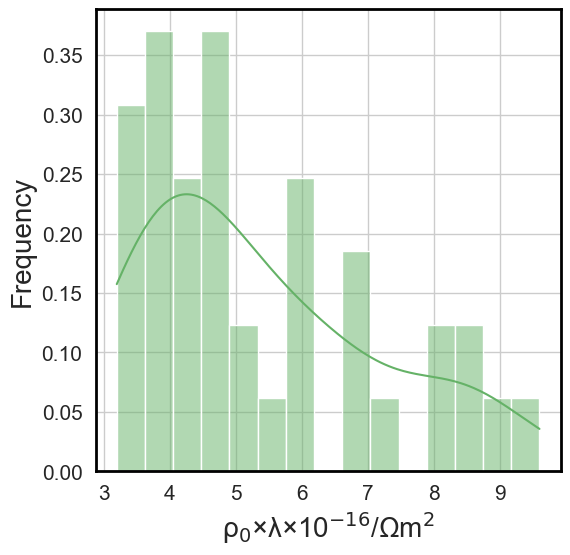

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from modules import *
import modules


def all_data(File):
    data1=open(File,'r+')
    all=[]
    for i, line in enumerate(data1):
        data=line.split()
        #for j in range(int(len(data))-2):
        #    X += [float(data[j+1])]
        for j in range(int(len(data))):
            all += [float(data[j])]
    m=len(all)
    
    all=np.array(all).reshape(int(627),int(m/627))
   
    return all


File = '../data.4/em-wt-10'
all= all_data(File)
all=all[:38,-1:]

# 将NumPy数组转换为Pandas DataFrame，并指定列名
df = pd.DataFrame(all, columns=['ρ0λ'])
sns.set(style="whitegrid")
plt.figure(figsize=(6,6))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
sns.histplot( data = df , x = 'ρ0λ', kde=True,color='#65B267',bins=15,stat='density')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(2)
# plt.title('Distribution of ρ0×λ', fontsize=20)
plt.xlabel('ρ$_0$×λ×10$^{-16}$/Ωm$^2$', fontsize=20)
plt.ylabel("Frequency", fontsize=20)

# 设置图形的风格
plt.savefig('38-distri.png.png',dpi=300,bbox_inches='tight')
plt.show()

               
#

## t-SNE数据分布

Org data dimension is 7.Embedded data dimension is 2


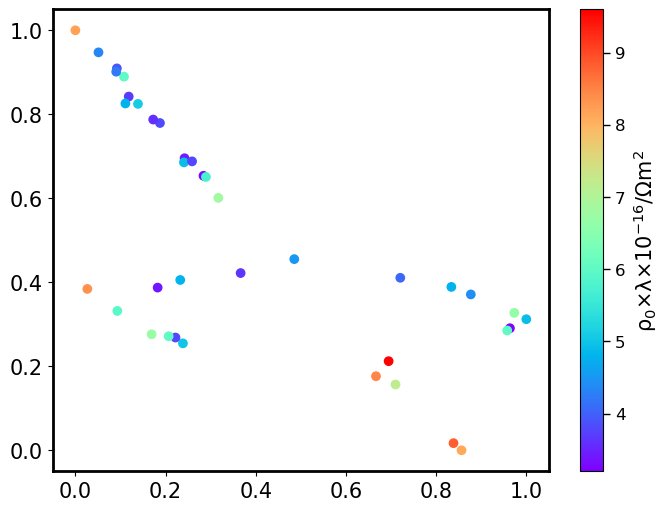

In [1]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn import manifold
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from modules import *
import seaborn as sns

def all_data(File):
    data1=open(File,'r+')
    all=[]
    for i, line in enumerate(data1):
        data=line.split()
        #for j in range(int(len(data))-2):
        #    X += [float(data[j+1])]
        for j in range(int(len(data))):
            all += [float(data[j])]
    m=len(all)
    
    all=np.array(all).reshape(int(627),int(m/627))
   
    return all

File = '../data.4/em-wt-10'
all_1 = all_data(File)
all_2=all_1[:38,:]
all_2=np.delete(all_2,[7],axis=1)
X=np.delete(all_2,[7],axis=1)
y=np.delete(all_2,[0,1,2,3,4,5,6],axis=1)

'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=501)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''

x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化

plt.figure(figsize=(8,6))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
cb.set_label('ρ$_0$×λ×10$^{-16}$/Ωm$^2$', fontsize=15)
#cb.ax.tick_params(length=2)
cb.ax.tick_params(size=5,width=1,labelsize=12)
plt.savefig('38-tSNE.png',dpi=300,bbox_inches='tight')
plt.show()


## 箱线图大致看数据分布，由于数据之间的差别过大归一化进行描述

In [ ]:
## scaler=StandardScaler()
scaler.fit(all)
all_1=scaler.transform(all)

# 指定列名
column_names = ['weight', 'VEC', 'AR','EN','Ea','1 st','boiling point','ρ0λ']
# 将NumPy数组转换为Pandas DataFrame，并指定列名
df_1 = pd.DataFrame(all_1, columns=column_names)

"""
箱线图

"""
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df_1)
ax.set_title('Boxplot for detecting outliers')
plt.show()

# 计算平均数、标准差、最小值、25%分位数、中位数、75%分位数和最大值
stats_1 = df_1.describe()
print(stats_1)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler(feature_range=(0,1))
scaler.fit(all)
all_2=scaler.transform(all)

# 指定列名
column_names = ['weight', 'VEC', 'AR','EN','Ea','1 st','boiling point','ρ0λ']
# 将NumPy数组转换为Pandas DataFrame，并指定列名
df_2 = pd.DataFrame(all_2, columns=column_names)

"""
箱线图
"""
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df_2)
ax.set_title('Boxplot for detecting outliers')
plt.show()

# 计算平均数、标准差、最小值、25%分位数、中位数、75%分位数和最大值
stats_2 = df_2.describe()
print(stats_2)

# 内聚能训练数据的特征分布情况

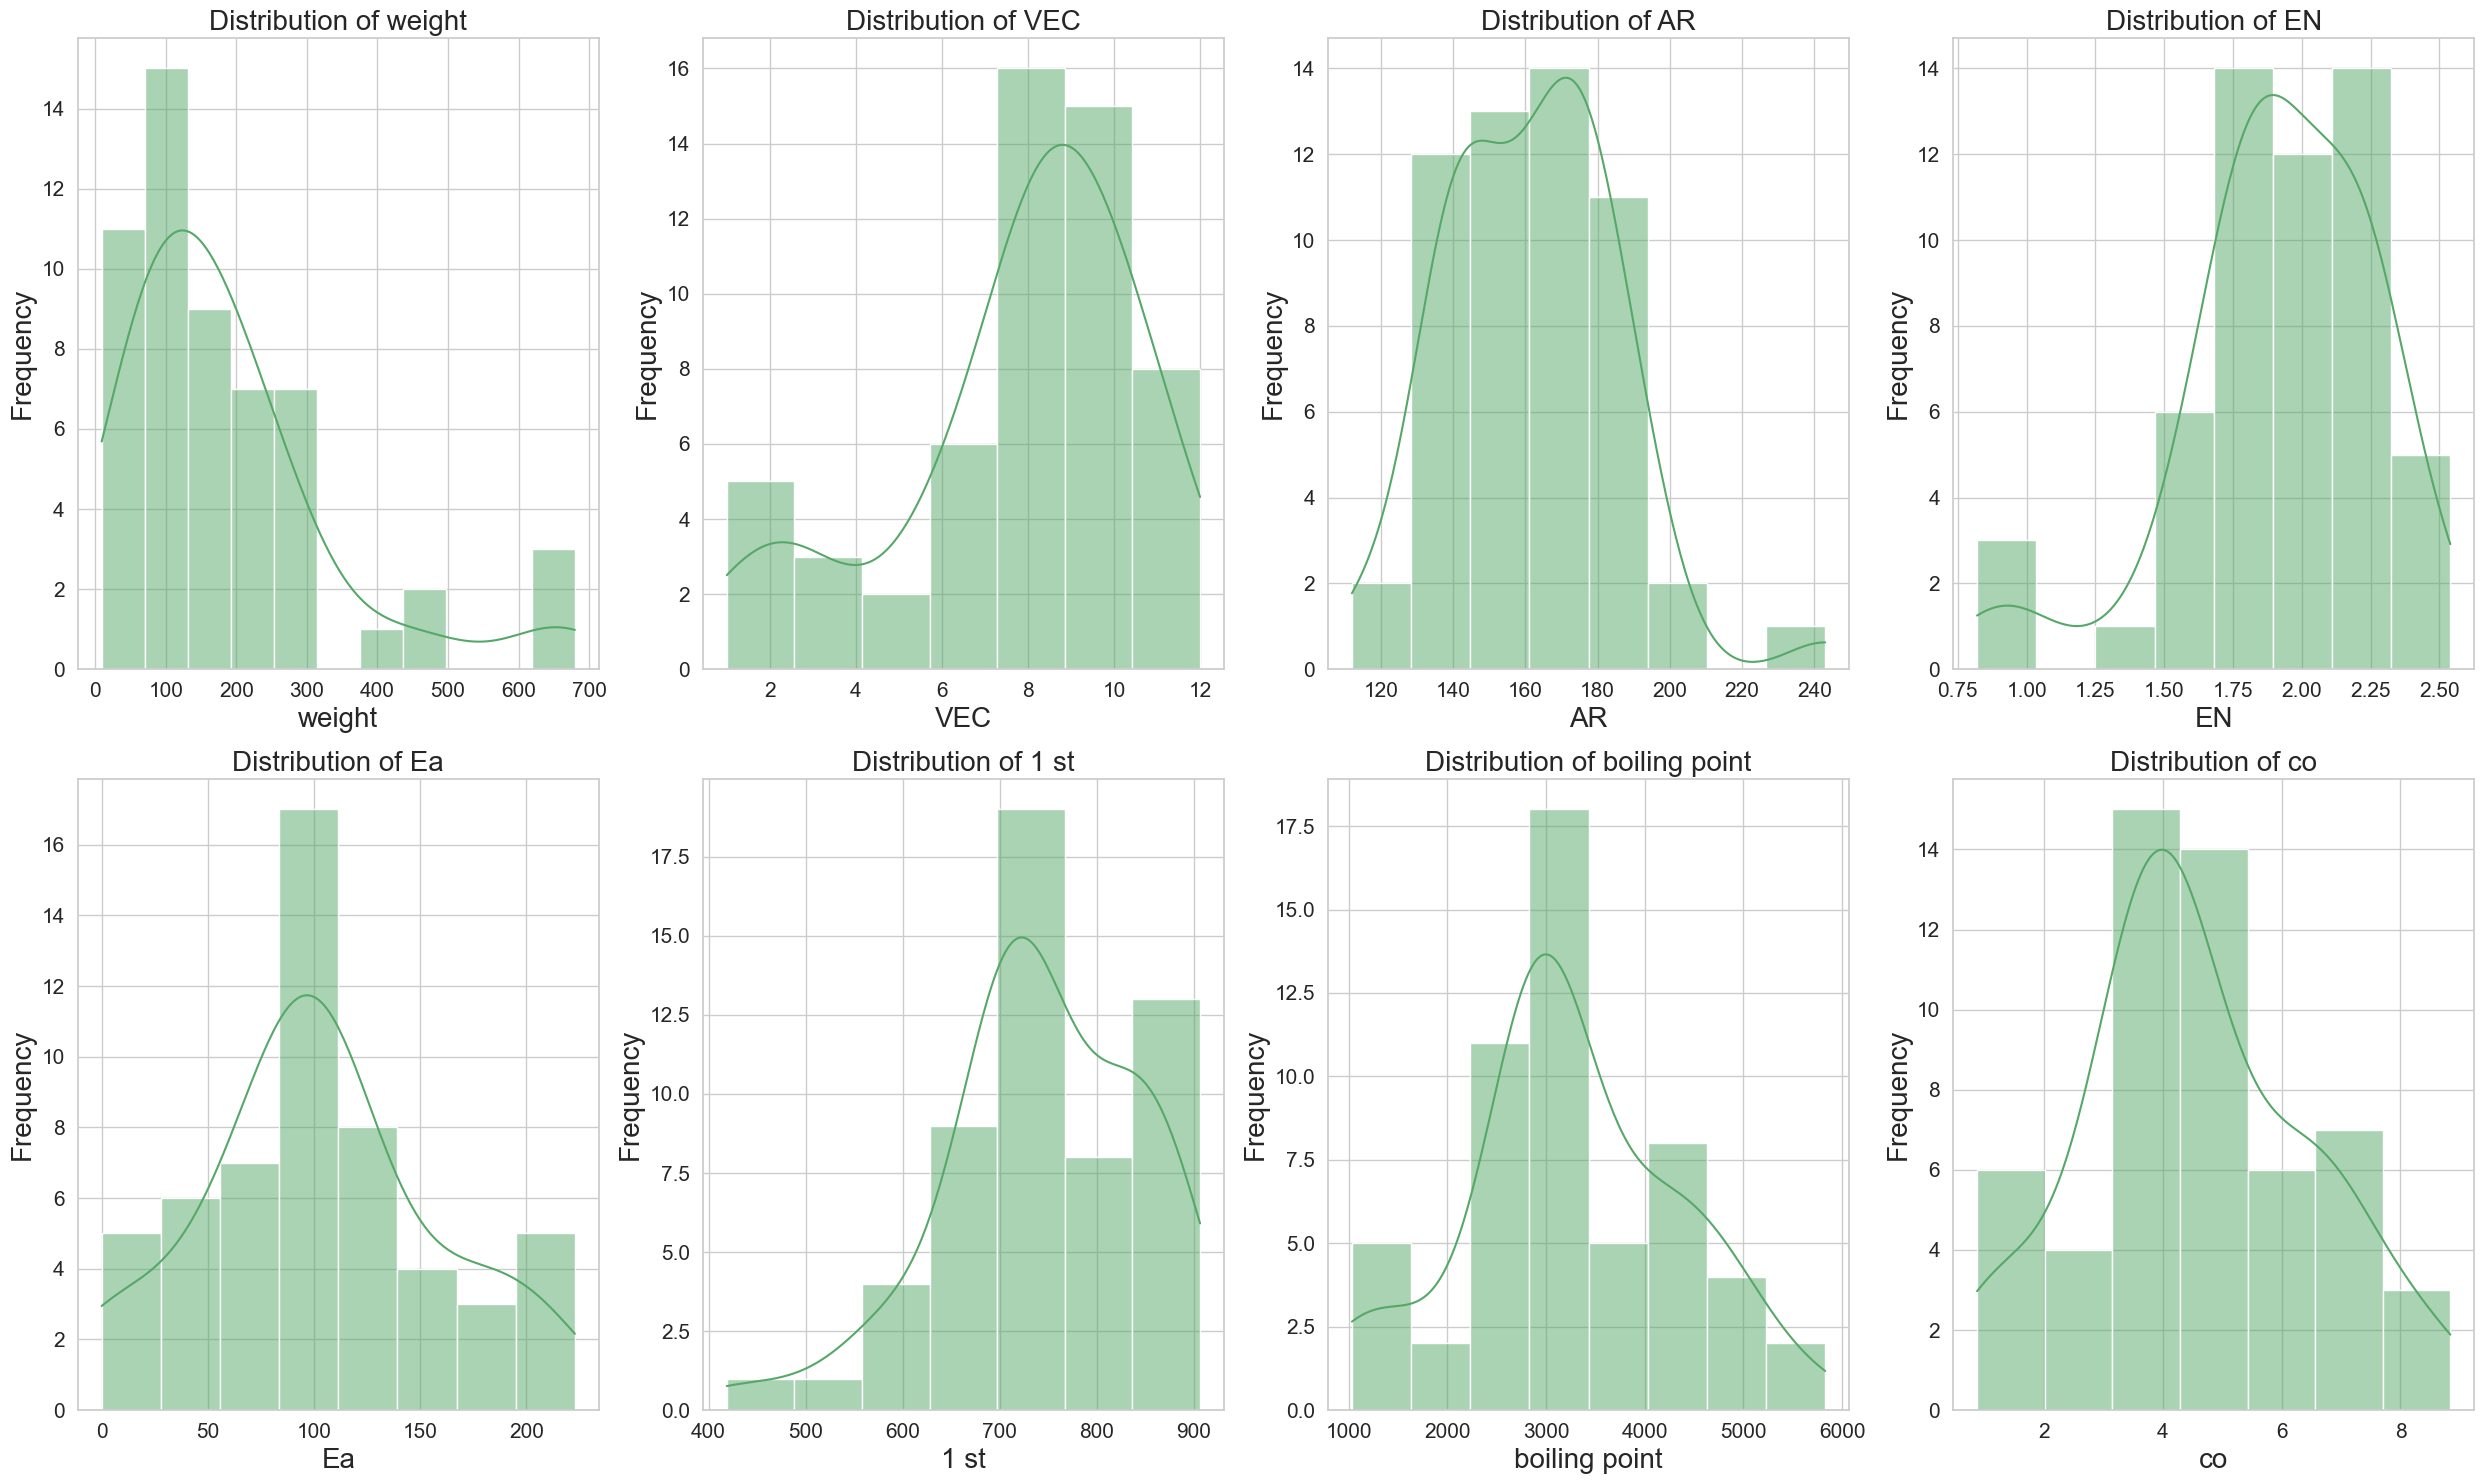

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from modules import *
import modules


def all_data(File):
    data1=open(File,'r+')
    all=[]
    for i, line in enumerate(data1):
        data=line.split()
        #for j in range(int(len(data))-2):
        #    X += [float(data[j+1])]
        for j in range(int(len(data))):
            all += [float(data[j])]
    m=len(all)
    
    all=np.array(all).reshape(int(639),int(m/639))
   
    return all


File = '../data.4/co-wt'
all= all_data(File)
all=all[:55,:]


# 指定列名
column_names = ['weight', 'VEC', 'AR','EN','Ea','1 st','boiling point','co']

# 将NumPy数组转换为Pandas DataFrame，并指定列名
df = pd.DataFrame(all, columns=column_names)
"""
直方图
"""
# 设置图形的风格
sns.set(style="whitegrid")
# 绘制特征的直方图
fig, axes = plt.subplots(2, 4, figsize=(25, 15))

axes = axes.flatten()  # 将二维数组展平为一维,遍历作图调整细节的关键

# 绘制每个特征列的分布图
for i, feature in enumerate(df.columns):
    ax = axes[i]
    sns.histplot(df[feature], ax=ax, kde=True,color='g')
    # 设置标题和轴标签
    ax.set_title(f'Distribution of {feature}', fontsize=20)
    ax.set_xlabel(feature, fontsize=20)
    ax.set_ylabel("Frequency", fontsize=20)
    # 调整刻度字体
    ax.tick_params(axis='both', labelsize=15)
    
# 绘制目标值的直方图
# plt.show()
# sns.histplot(df['ρ0λ'], kde=True)
# plt.title('Distribution of Target')
# plt.show()


plt.tight_layout()
plt.savefig('55-distri.png',dpi=300,bbox_inches='tight')
plt.show()

In [6]:
stats = df.describe()
print(stats)

           weight        VEC          AR         EN          Ea        1 st  \
count   55.000000  55.000000   55.000000  55.000000   55.000000   55.000000   
mean   186.059388   7.804256  161.576011   1.919768  102.075280  743.152401   
std    152.961558   2.842945   23.298749   0.355828   56.322901  102.964233   
min      9.010000   1.000000  112.000000   0.820000    0.000000  418.800000   
25%     91.716954   6.732402  143.500000   1.773412   71.348183  691.132632   
50%    145.691538   8.386988  165.000000   1.929737   97.357353  737.100000   
75%    215.478169   9.792484  177.347697   2.200000  129.736410  826.124209   
max    679.840154  12.000000  243.000000   2.540000  222.800000  906.400000   

       boiling point         co  
count      55.000000  55.000000  
mean     3252.050620   4.521855  
std      1090.656908   1.904407  
min      1032.000000   0.870000  
25%      2816.761269   3.495000  
50%      3100.452905   4.300000  
75%      4008.863650   5.840000  
max      5828.00

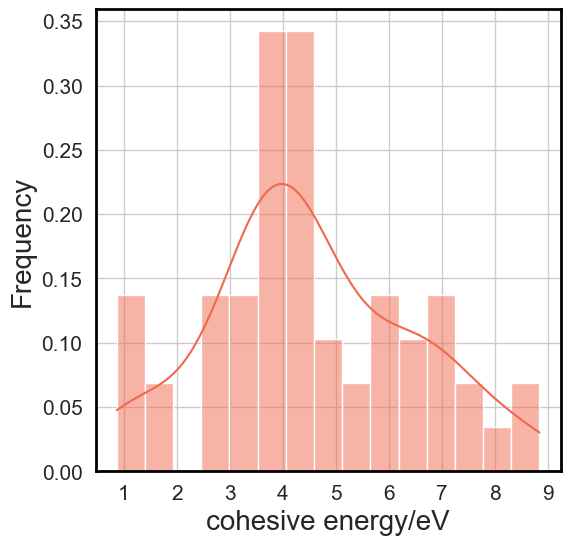

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from modules import *
import modules


def all_data(File):
    data1=open(File,'r+')
    all=[]
    for i, line in enumerate(data1):
        data=line.split()
        #for j in range(int(len(data))-2):
        #    X += [float(data[j+1])]
        for j in range(int(len(data))):
            all += [float(data[j])]
    m=len(all)
    
    all=np.array(all).reshape(int(639),int(m/639))
   
    return all


File = '../data.4/co-wt'
all= all_data(File)
all=all[:55,-1:]

# 将NumPy数组转换为Pandas DataFrame，并指定列名
df = pd.DataFrame(all, columns=['co'])
sns.set(style="whitegrid")
plt.figure(figsize=(6,6))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(2)
sns.histplot( data = df , x = 'co', kde=True,color='#F0694C',bins=15,stat='density')
# plt.title('Distribution of cohesive energy', fontsize=20)
plt.xlabel('cohesive energy/eV', fontsize=20)
plt.ylabel("Frequency", fontsize=20)

# 设置图形的风格
plt.savefig('Co-distri.png',dpi=300,bbox_inches='tight')
plt.show()

               
#

## t-SNE数据分布

Org data dimension is 7.Embedded data dimension is 2


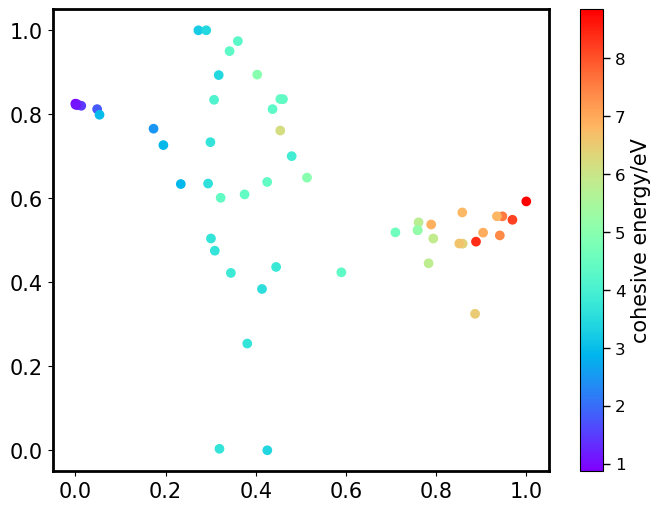

In [5]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn import manifold
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from modules import *
import seaborn as sns

def all_data(File):
    data1=open(File,'r+')
    all=[]
    for i, line in enumerate(data1):
        data=line.split()
        #for j in range(int(len(data))-2):
        #    X += [float(data[j+1])]
        for j in range(int(len(data))):
            all += [float(data[j])]
    m=len(all)
    
    all=np.array(all).reshape(int(639),int(m/639))
   
    return all


File = '../data.4/co-wt'
co= all_data(File)
co=co[:55,:]

X=np.delete(co,[7],axis=1)
y=np.delete(co,[0,1,2,3,4,5,6],axis=1)

'''t-SNE'''
tsne = manifold.TSNE(n_components=2,init='pca', random_state=501)
X_tsne = tsne.fit_transform(X)
print("Org data dimension is {}.Embedded data dimension is {}".format(X.shape[-1], X_tsne.shape[-1]))
 
'''visualization'''

x_min, x_max = X_tsne.min(0), X_tsne.max(0)
X_norm = (X_tsne - x_min) / (x_max - x_min)  # 归一化

plt.figure(figsize=(8,6))
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)

path=plt.scatter(X_norm[:, 0], X_norm[:, 1],c=y, cmap=plt.cm.rainbow)
cb=plt.colorbar(drawedges=False, orientation='vertical',spacing='uniform')
cb.set_label('cohesive energy/eV', fontsize=15)
#cb.ax.tick_params(length=2)
cb.ax.tick_params(size=5,width=1,labelsize=12)
plt.savefig('55-tSNE.png',dpi=300,bbox_inches='tight')
plt.show()


## 内聚能箱线图 由于沸点过高压缩整体的图形

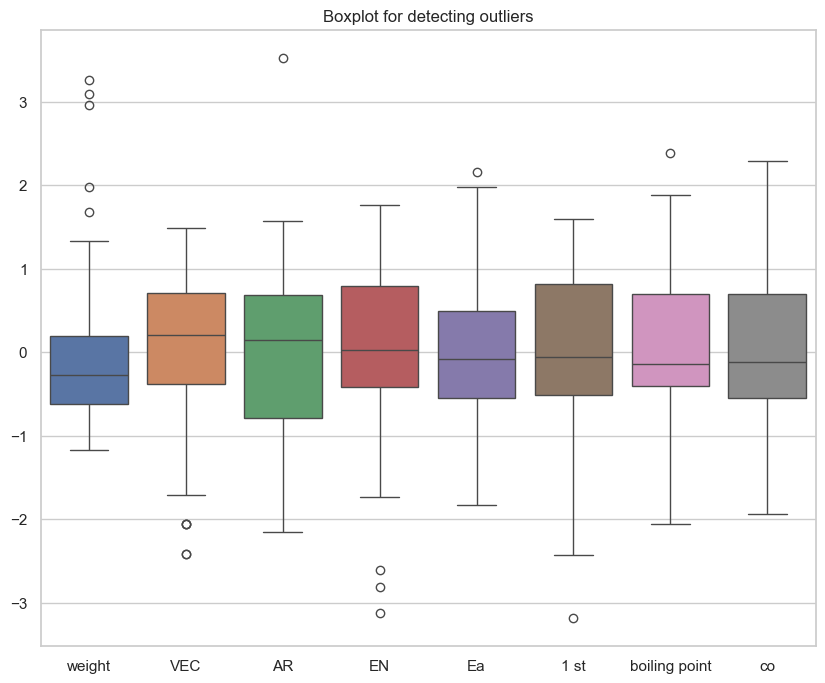

             weight           VEC            AR            EN            Ea  \
count  5.500000e+01  5.500000e+01  5.500000e+01  5.500000e+01  5.500000e+01   
mean   2.376887e-16 -4.562007e-16  6.338364e-16 -1.076916e-15 -1.009294e-16   
std    1.009217e+00  1.009217e+00  1.009217e+00  1.009217e+00  1.009217e+00   
min   -1.168145e+00 -2.415443e+00 -2.147452e+00 -3.119214e+00 -1.829027e+00   
25%   -6.224568e-01 -3.804975e-01 -7.829868e-01 -4.151004e-01 -5.505807e-01   
50%   -2.663409e-01  2.068640e-01  1.483147e-01  2.827452e-02 -8.453775e-02   
75%    1.941006e-01  7.058008e-01  6.831719e-01  7.948076e-01  4.956435e-01   
max    3.257889e+00  1.489447e+00  3.526990e+00  1.759132e+00  2.163195e+00   

               1 st  boiling point            co  
count  5.500000e+01   5.500000e+01  5.500000e+01  
mean  -9.164386e-16   1.213171e-15 -1.665335e-16  
std    1.009217e+00   1.009217e+00  1.009217e+00  
min   -3.179181e+00  -2.054278e+00 -1.935255e+00  
25%   -5.098783e-01  -4.027860e-0

In [13]:
scaler=StandardScaler()
scaler.fit(all)
all_1=scaler.transform(all)

# 指定列名
column_names = ['weight', 'VEC', 'AR','EN','Ea','1 st','boiling point','co']
# 将NumPy数组转换为Pandas DataFrame，并指定列名
df_1 = pd.DataFrame(all_1, columns=column_names)

"""
箱线图

"""
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df_1)
ax.set_title('Boxplot for detecting outliers')
plt.show()

# 计算平均数、标准差、最小值、25%分位数、中位数、75%分位数和最大值
stats_1 = df_1.describe()
print(stats_1)

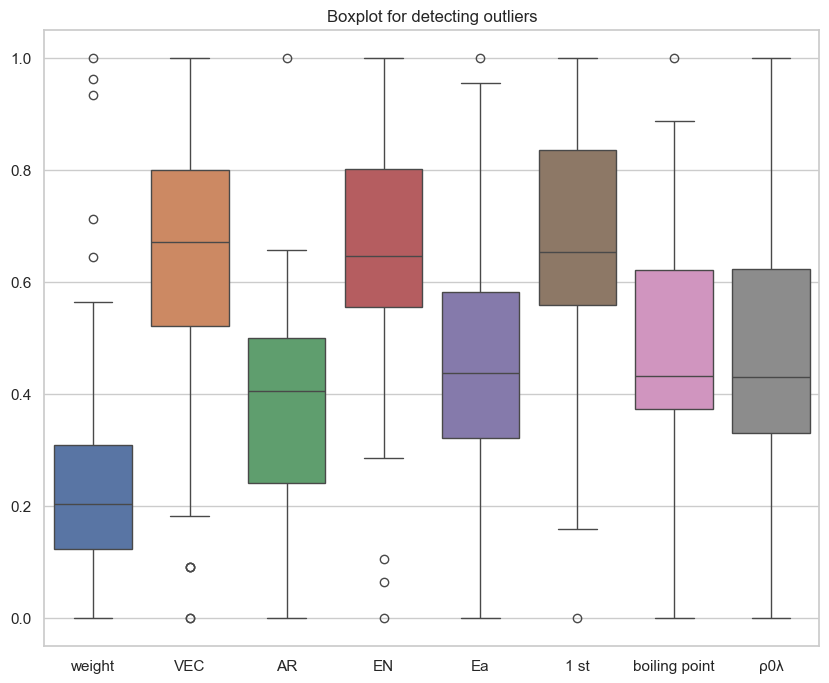

          weight        VEC         AR         EN         Ea       1 st  \
count  55.000000  55.000000  55.000000  55.000000  55.000000  55.000000   
mean    0.263926   0.618569   0.378443   0.639400   0.458148   0.665202   
std     0.228018   0.258450   0.177853   0.206877   0.252796   0.211165   
min     0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
25%     0.123290   0.521127   0.240458   0.554310   0.320234   0.558516   
50%     0.203750   0.671544   0.404580   0.645196   0.436972   0.652789   
75%     0.307780   0.799317   0.498837   0.802326   0.582300   0.835365   
max     1.000000   1.000000   1.000000   1.000000   1.000000   1.000000   

       boiling point        ρ0λ  
count      55.000000  55.000000  
mean        0.462896   0.458200  
std         0.227410   0.238947  
min         0.000000   0.000000  
25%         0.372135   0.329360  
50%         0.431287   0.430364  
75%         0.620697   0.623588  
max         1.000000   1.000000  


In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
scaler.fit(all)
all_2=scaler.transform(all)

# 指定列名
column_names = ['weight', 'VEC', 'AR','EN','Ea','1 st','boiling point','ρ0λ']
# 将NumPy数组转换为Pandas DataFrame，并指定列名
df_2 = pd.DataFrame(all_2, columns=column_names)

"""
箱线图
"""
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df_2)
ax.set_title('Boxplot for detecting outliers')
plt.show()

# 计算平均数、标准差、最小值、25%分位数、中位数、75%分位数和最大值
stats_2 = df_2.describe()
print(stats_2)

# 